# Exploration du Dataset Housing

Analyse exploratoire du dataset `Housing.csv` — prix et caractéristiques de logements.


## 1. Import des bibliothèques


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Chargement du Dataset


In [2]:
df = pd.read_csv("Housing.csv")
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()


Dataset chargé : 545 lignes, 13 colonnes


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Vue d'ensemble du Dataset


In [3]:
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes\n")

print("=== Types des colonnes ===")
print(df.dtypes)

print("\n=== Informations générales ===")
df.info()


Dimensions : 545 lignes × 13 colonnes

=== Types des colonnes ===
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   h

## 4. Résumé Statistique


In [4]:
print("=== Variables numériques ===")
display(df.describe())

print("\n=== Variables catégorielles ===")
display(df.describe(include="object"))


=== Variables numériques ===


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



=== Variables catégorielles ===


C:\Users\fiokl\AppData\Local\Temp\ipykernel_24076\909514784.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


## 5. Analyse des Valeurs Manquantes


Aucune valeur manquante détectée.


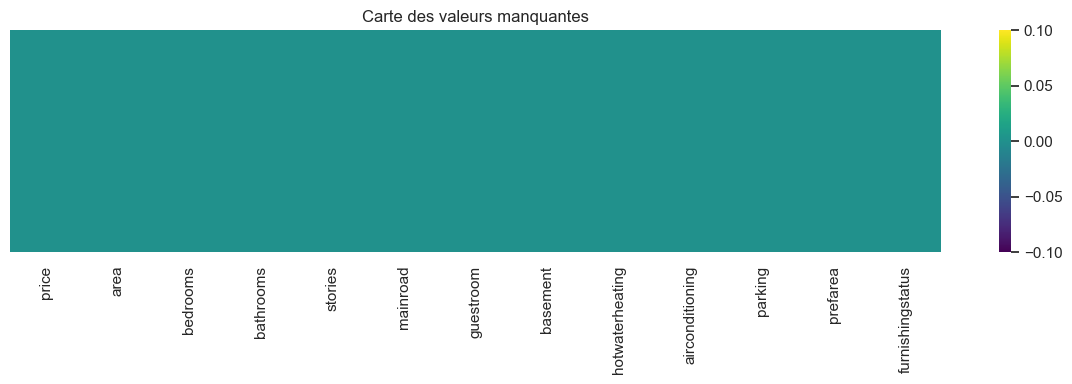

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Valeurs manquantes": missing, "Pourcentage (%)": missing_pct})

if missing.sum() == 0:
    print("Aucune valeur manquante détectée.")
else:
    print("Colonnes avec valeurs manquantes :")
    display(missing_df[missing_df["Valeurs manquantes"] > 0])

# Heatmap des valeurs manquantes
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap="viridis")
plt.title("Carte des valeurs manquantes")
plt.tight_layout()
plt.show()


## 6. Visualisation des Distributions


In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Colonnes numériques ({len(num_cols)}) : {num_cols}")
print(f"Colonnes catégorielles ({len(cat_cols)}) : {cat_cols}")


Colonnes numériques (6) : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Colonnes catégorielles (7) : ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


C:\Users\fiokl\AppData\Local\Temp\ipykernel_24076\1110162901.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


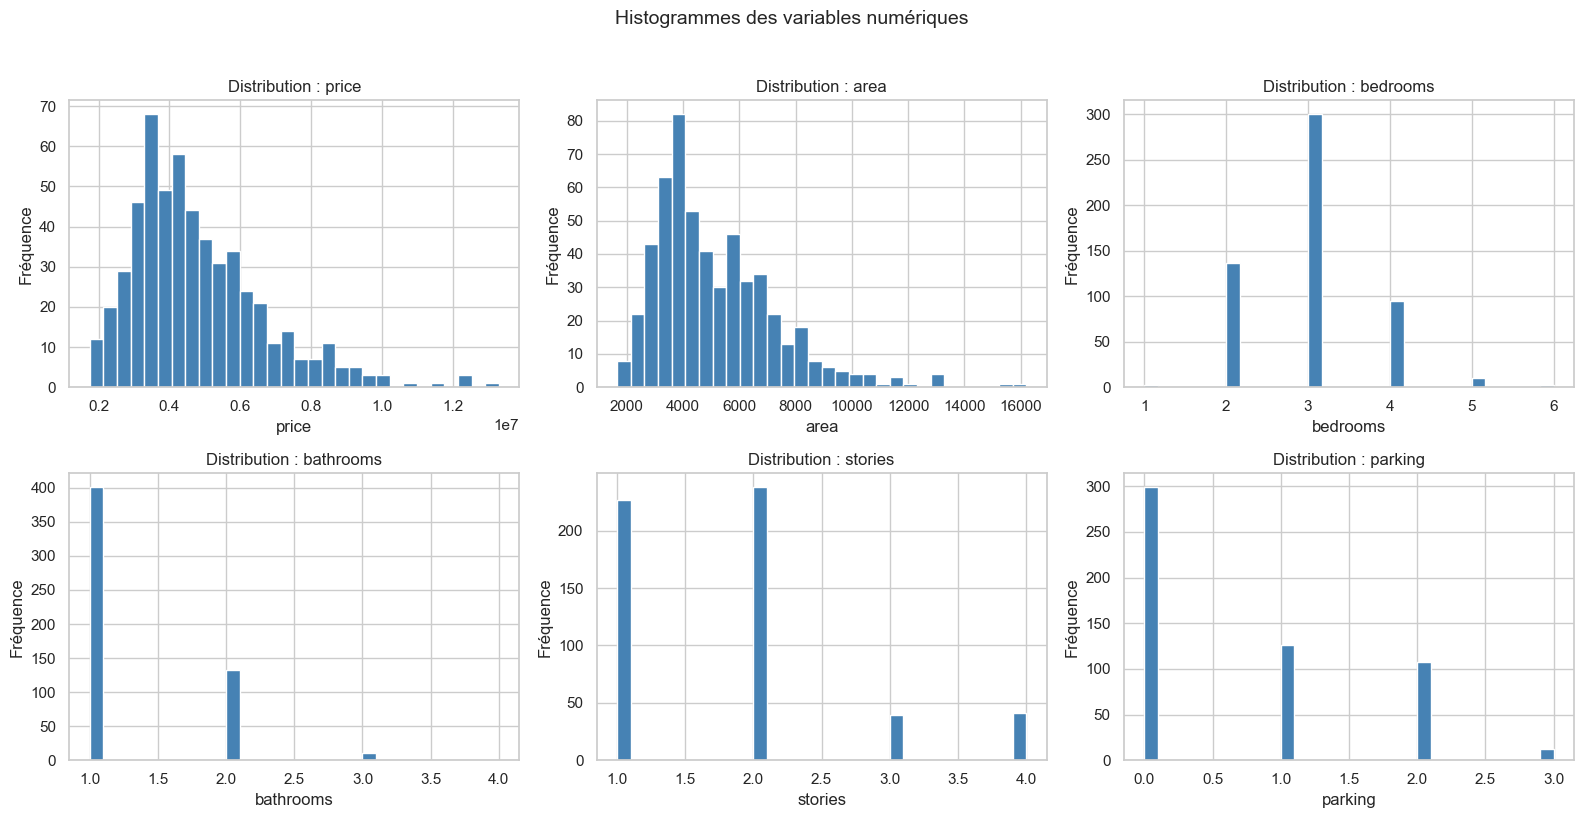

In [7]:
# Histogrammes des variables numériques
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(f"Distribution : {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogrammes des variables numériques", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


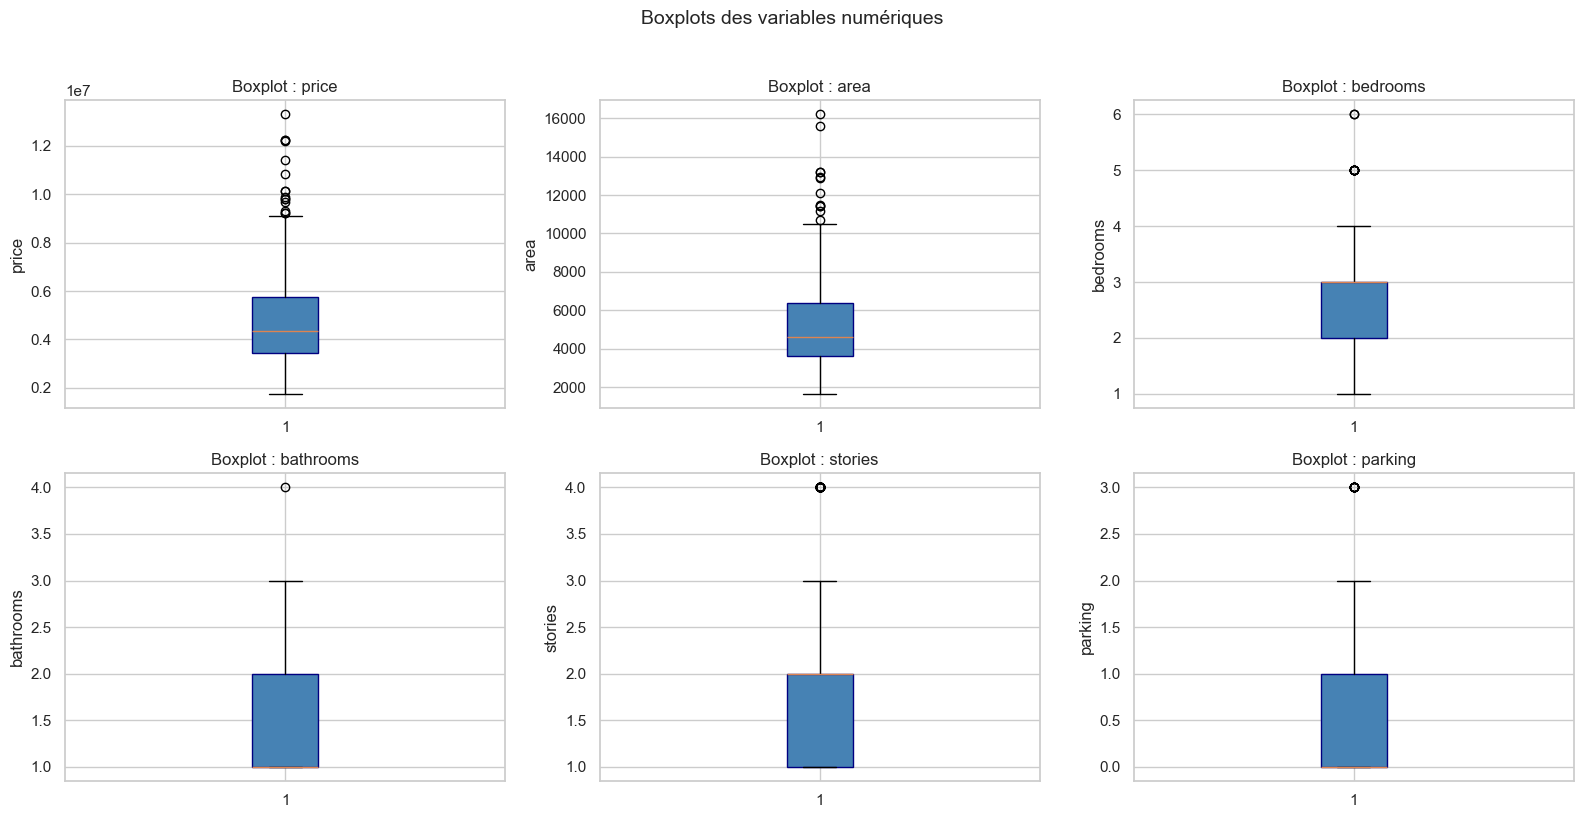

In [8]:
# Boxplots des variables numériques
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", color="navy"))
    axes[i].set_title(f"Boxplot : {col}")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots des variables numériques", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


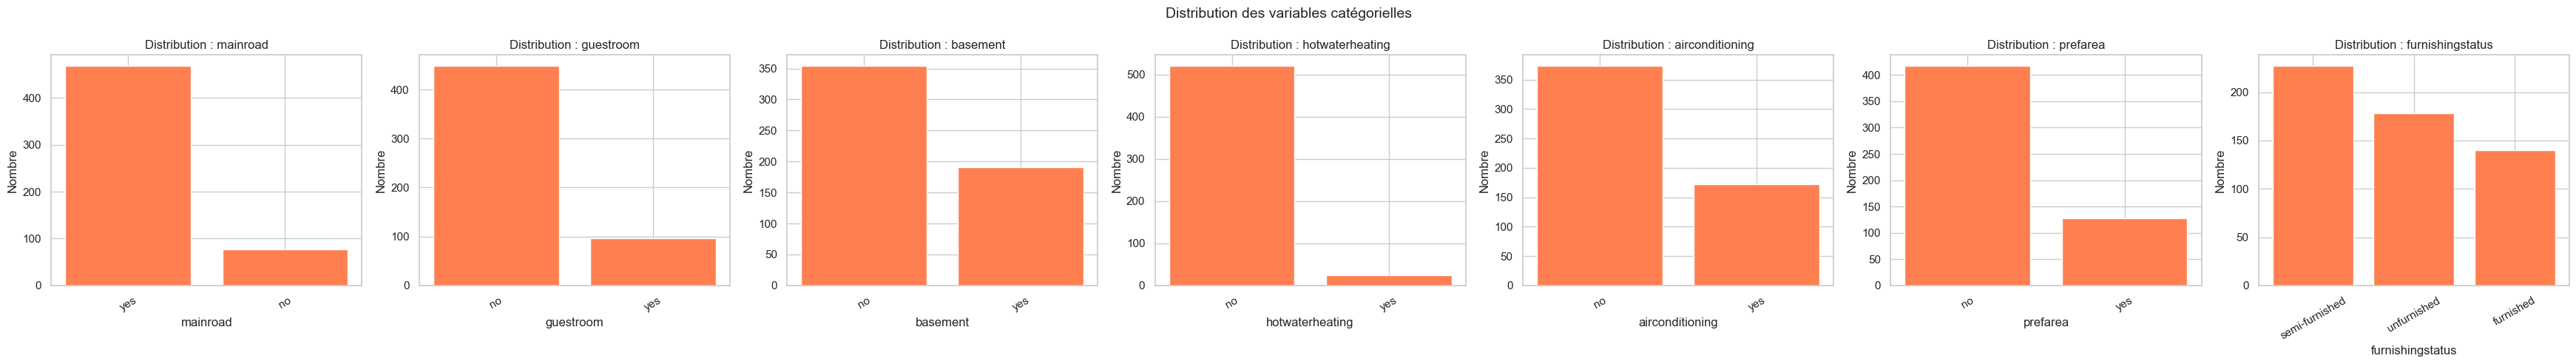

In [9]:
# Bar charts des variables catégorielles
if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))
    if len(cat_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols):
        counts = df[col].value_counts()
        ax.bar(counts.index, counts.values, color="coral", edgecolor="white")
        ax.set_title(f"Distribution : {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Nombre")
        ax.tick_params(axis="x", rotation=30)
    plt.suptitle("Distribution des variables catégorielles", fontsize=14)
    plt.tight_layout()
    plt.show()


## 7. Analyse de Corrélation


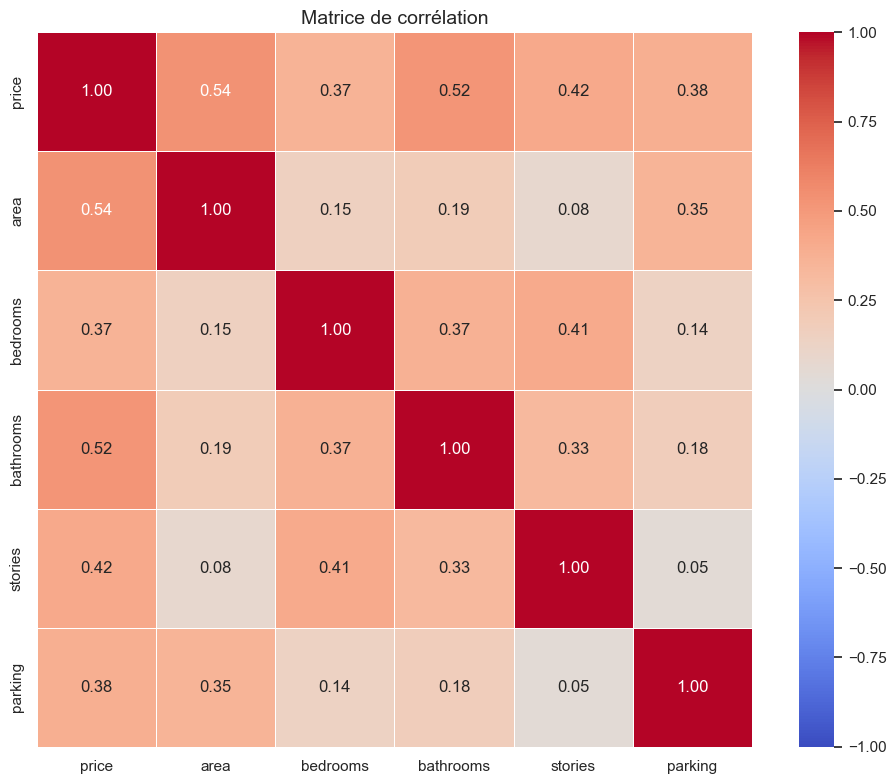

In [10]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Matrice de corrélation", fontsize=14)
plt.tight_layout()
plt.show()


=== Corrélations avec 'price' ===
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


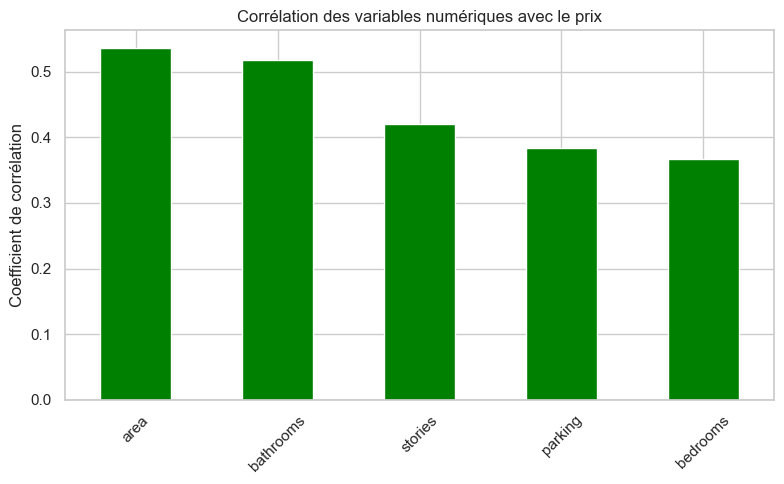

In [11]:
# Corrélations avec la variable cible 'price'
corr_price = corr_matrix["price"].drop("price").sort_values(ascending=False)
print("=== Corrélations avec 'price' ===")
print(corr_price)

plt.figure(figsize=(8, 5))
colors = ["green" if v > 0 else "red" for v in corr_price]
corr_price.plot(kind="bar", color=colors)
plt.title("Corrélation des variables numériques avec le prix")
plt.ylabel("Coefficient de corrélation")
plt.xticks(rotation=45)
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## 8. Prédiction du Prix avec AdaBoostRegressor

Nous allons utiliser **AdaBoost** pour prédire la variable `price` à partir des autres caractéristiques, après encodage des variables catégorielles.

### 8.1 Préparation des données (encodage)

In [12]:
df_model = df.copy()

# Encodage binaire yes/no → 0/1
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df_model[col] = (df_model[col] == "yes").astype(int)

# Encodage ordinal furnishingstatus
furnishing_map = {"unfurnished": 0, "semi-furnished": 1, "furnished": 2}
df_model["furnishingstatus"] = df_model["furnishingstatus"].map(furnishing_map)

print("Aperçu après encodage :")
display(df_model.head())

Aperçu après encodage :


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


### 8.2 Split Train / Test

In [14]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille train : {X_train.shape[0]} échantillons")
print(f"Taille test  : {X_test.shape[0]} échantillons")
print(f"Features     : {X.columns.tolist()}")

Taille train : 436 échantillons
Taille test  : 109 échantillons
Features     : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


### 8.3 Modèle de référence — Arbre de Décision (sans Boosting)

Avant d'utiliser AdaBoost, on entraîne un **arbre de décision simple** (même profondeur `max_depth=4`) pour avoir une **baseline** de comparaison. Cela permet de mesurer le gain réel apporté par le boosting.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Arbre de décision simple — même profondeur que le base learner d'AdaBoost
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print("=== Baseline — Arbre de Décision (max_depth=4) ===")
print(f"MAE  : {mae_dt:>15,.0f}")
print(f"RMSE : {rmse_dt:>15,.0f}")
print(f"R²   : {r2_dt:.4f}")

# Scatter : réel vs prédit
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_dt, alpha=0.6, color="gray", edgecolor="white")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "r--", linewidth=1.5, label="Prédiction parfaite")
plt.title(f"Baseline — Arbre de Décision\nR² = {r2_dt:.4f}", fontsize=11)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 Entraînement du AdaBoostRegressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Apprenant faible : arbre de profondeur 4
base_learner = DecisionTreeRegressor(max_depth=4, random_state=42)

ada_model = AdaBoostRegressor(
    estimator=base_learner,
    n_estimators=100,
    learning_rate=0.1,
    loss="linear",
    random_state=42
)

ada_model.fit(X_train, y_train)
print(f"Modèle entraîné avec {ada_model.n_estimators} estimateurs.")

### 8.4 Évaluation du modèle

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = ada_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Métriques sur le jeu de test ===")
print(f"MAE  (erreur absolue moyenne) : {mae:>15,.0f}")
print(f"RMSE (racine erreur quadr.)   : {rmse:>15,.0f}")
print(f"R²   (coefficient détermination) : {r2:.4f}")

### 8.5 AdaBoost Implémenté from Scratch

Implémentation de l'algorithme **AdaBoost.R2** (Drucker et al., 1997) sans utiliser sklearn — uniquement numpy et `DecisionTreeRegressor` comme apprenant faible.

In [ ]:
class AdaBoostRegressorScratch:
    """
    AdaBoost.R2 (Drucker et al., 1997) implémenté from scratch.
    Utilise la perte linéaire : L_i = |y_i - ŷ_i| / max|y - ŷ|
    Prédiction finale : médiane pondérée des estimateurs.
    """

    def __init__(self, n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42):
        self.n_estimators  = n_estimators
        self.max_depth     = max_depth
        self.learning_rate = learning_rate
        self.random_state  = random_state

    def fit(self, X, y):
        rng   = np.random.RandomState(self.random_state)
        X_arr = X.values if hasattr(X, "values") else np.asarray(X)
        y_arr = y.values if hasattr(y, "values") else np.asarray(y, dtype=float)
        n     = len(y_arr)

        self.estimators_   = []
        self.betas_        = []
        self.train_losses_ = []   # ε_t pour chaque itération

        weights = np.full(n, 1.0 / n)  # poids initiaux uniformes

        for t in range(self.n_estimators):
            # 1. Tirage pondéré avec remise
            idx = rng.choice(n, size=n, replace=True, p=weights)

            # 2. Entraîner l'apprenant faible sur l'échantillon pondéré
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state + t
            )
            tree.fit(X_arr[idx], y_arr[idx])

            # 3. Prédictions sur tout l'ensemble d'entraînement
            preds   = tree.predict(X_arr)
            abs_err = np.abs(y_arr - preds)
            max_err = abs_err.max()

            if max_err == 0:
                self.estimators_.append(tree); self.betas_.append(0.0)
                self.train_losses_.append(0.0); break

            # 4. Perte normalisée L_i ∈ [0, 1]
            L   = abs_err / max_err
            eps = float(weights @ L)   # ε_t = perte pondérée

            if eps >= 0.5 or eps == 0:  # estimateur trop faible → arrêt
                break

            # 5. β_t = (ε_t / (1 - ε_t)) ^ learning_rate
            beta = (eps / (1.0 - eps)) ** self.learning_rate

            # 6. Mise à jour des poids : plus de poids aux mal prédits
            weights *= beta ** (1.0 - L)
            weights /= weights.sum()  # renormalisation

            self.estimators_.append(tree)
            self.betas_.append(beta)
            self.train_losses_.append(eps)

        return self

    def predict(self, X):
        X_arr    = X.values if hasattr(X, "values") else np.asarray(X)
        all_pred = np.array([est.predict(X_arr) for est in self.estimators_])  # (T, n)

        # Poids de chaque estimateur : log(1/β_t)
        w = np.array([np.log(1.0 / (b + 1e-10)) for b in self.betas_])
        w = np.maximum(w, 0.0)
        if w.sum() == 0:
            return all_pred.mean(axis=0)
        w /= w.sum()

        # Médiane pondérée pour chaque observation
        n_s    = all_pred.shape[1]
        result = np.empty(n_s)
        for i in range(n_s):
            order      = np.argsort(all_pred[:, i])
            cumw       = np.cumsum(w[order])
            k          = min(np.searchsorted(cumw, 0.5), len(order) - 1)
            result[i]  = all_pred[order[k], i]
        return result


# ─── Entraînement ──────────────────────────────────────────────────────────
ada_scratch = AdaBoostRegressorScratch(
    n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
)
ada_scratch.fit(X_train, y_train)
y_pred_scratch = ada_scratch.predict(X_test)

print(f"Estimateurs construits : {len(ada_scratch.estimators_)} / {ada_scratch.n_estimators}")

### 8.6 Comparaison Scratch vs Sklearn — Toutes les métriques

In [ ]:

# ── Métriques complètes ────────────────────────────────────────────────────
ada_metrics = {
    "Baseline (Arbre seul)": y_pred_dt,
    "Scratch (AdaBoost.R2)": y_pred_scratch,
    "Sklearn (AdaBoostRegressor)": y_pred,
}

rows = []
for label, y_p in ada_metrics.items():
    rows.append({
        "Modèle": label,
        "MAE": mean_absolute_error(y_test, y_p),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_p)),
        "R²": r2_score(y_test, y_p),
    })

metrics_df = pd.DataFrame(rows).set_index("Modèle")
print("=== Comparaison AdaBoost — Baseline vs Scratch vs Sklearn ===")
display(metrics_df.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.4f}"}))

# ── Scatter : 3 modèles côte à côte ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["gray", "darkorange", "steelblue"]

for ax, (label, y_p), color in zip(axes, ada_metrics.items(), colors):
    r2_val   = r2_score(y_test, y_p)
    mae_val  = mean_absolute_error(y_test, y_p)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_p))
    ax.scatter(y_test, y_p, alpha=0.6, color=color, edgecolor="white")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            "r--", linewidth=1.5, label="Prédiction parfaite")
    ax.set_title(
        f"{label}\nR²={r2_val:.4f}  |  MAE={mae_val:,.0f}  |  RMSE={rmse_val:,.0f}",
        fontsize=9
    )
    ax.set_xlabel("Prix réel")
    ax.set_ylabel("Prix prédit")
    ax.legend(fontsize=8)

plt.suptitle("AdaBoost — Baseline vs Scratch vs Sklearn", fontsize=13)
plt.tight_layout()
plt.show()


## 9. Gradient Boosting — Sklearn vs From Scratch

Le **Gradient Boosting** construit les arbres de manière séquentielle en corrigeant les **résidus** (erreurs) de l'itération précédente, contrairement à AdaBoost qui ajuste les poids des observations.

$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

où $h_t$ est un arbre entraîné sur les résidus $r_i = y_i - F_{t-1}(x_i)$ et $\eta$ le learning rate.

### 9.1 Gradient Boosting Sklearn

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_sklearn = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    loss="squared_error",
    random_state=42
)
gb_sklearn.fit(X_train, y_train)
y_pred_gb_sklearn = gb_sklearn.predict(X_test)

r2_gb_sklearn = r2_score(y_test, y_pred_gb_sklearn)
print(f"Gradient Boosting Sklearn — R² : {r2_gb_sklearn:.4f}")

### 9.2 Gradient Boosting From Scratch

Implémentation de base du **Gradient Boosting pour la régression MSE** :
- Initialisation : prédiction = moyenne de y
- À chaque itération : entraîner un arbre sur les résidus $r_i = y_i - F_{t-1}(x_i)$
- Mise à jour : $F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$

In [ ]:
class GradientBoostingRegressorScratch:
    """
    Gradient Boosting pour la régression (perte MSE).
    Algorithme :
      1. F_0(x) = mean(y)
      2. Pour t = 1..T :
         a. Résidus r_i = y_i - F_{t-1}(x_i)
         b. Entraîner un arbre h_t sur (X, r)
         c. F_t(x) = F_{t-1}(x) + learning_rate * h_t(x)
    """

    def __init__(self, n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42):
        self.n_estimators  = n_estimators
        self.max_depth     = max_depth
        self.learning_rate = learning_rate
        self.random_state  = random_state

    def fit(self, X, y):
        X_arr = X.values if hasattr(X, "values") else np.asarray(X)
        y_arr = y.values if hasattr(y, "values") else np.asarray(y, dtype=float)

        # Initialisation : prédire la moyenne
        self.F0_ = y_arr.mean()
        F = np.full(len(y_arr), self.F0_)

        self.estimators_ = []

        for t in range(self.n_estimators):
            # Résidus = gradient négatif de la MSE
            residuals = y_arr - F

            # Arbre entraîné sur les résidus
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state + t
            )
            tree.fit(X_arr, residuals)

            # Mise à jour du modèle
            F += self.learning_rate * tree.predict(X_arr)
            self.estimators_.append(tree)

        return self

    def predict(self, X):
        X_arr = X.values if hasattr(X, "values") else np.asarray(X)
        F = np.full(X_arr.shape[0], self.F0_)
        for tree in self.estimators_:
            F += self.learning_rate * tree.predict(X_arr)
        return F


# ─── Entraînement ──────────────────────────────────────────────────────────
gb_scratch = GradientBoostingRegressorScratch(
    n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
)
gb_scratch.fit(X_train, y_train)
y_pred_gb_scratch = gb_scratch.predict(X_test)

r2_gb_scratch = r2_score(y_test, y_pred_gb_scratch)
print(f"Gradient Boosting Scratch  — R² : {r2_gb_scratch:.4f}")

### 9.3 Comparaison Scratch vs Sklearn — Toutes les métriques

In [ ]:

# ── Métriques complètes ────────────────────────────────────────────────────
gb_metrics = {
    "Baseline (Arbre seul)": y_pred_dt,
    "Scratch (GB.MSE)": y_pred_gb_scratch,
    "Sklearn (GradientBoosting)": y_pred_gb_sklearn,
}

rows = []
for label, y_p in gb_metrics.items():
    rows.append({
        "Modèle": label,
        "MAE": mean_absolute_error(y_test, y_p),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_p)),
        "R²": r2_score(y_test, y_p),
    })

metrics_df = pd.DataFrame(rows).set_index("Modèle")
print("=== Comparaison Gradient Boosting — Baseline vs Scratch vs Sklearn ===")
display(metrics_df.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.4f}"}))

# ── Scatter : 3 modèles côte à côte ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["gray", "darkorange", "steelblue"]

for ax, (label, y_p), color in zip(axes, gb_metrics.items(), colors):
    r2_val   = r2_score(y_test, y_p)
    mae_val  = mean_absolute_error(y_test, y_p)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_p))
    ax.scatter(y_test, y_p, alpha=0.6, color=color, edgecolor="white")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            "r--", linewidth=1.5, label="Prédiction parfaite")
    ax.set_title(
        f"{label}\nR²={r2_val:.4f}  |  MAE={mae_val:,.0f}  |  RMSE={rmse_val:,.0f}",
        fontsize=9
    )
    ax.set_xlabel("Prix réel")
    ax.set_ylabel("Prix prédit")
    ax.legend(fontsize=8)

plt.suptitle("Gradient Boosting — Baseline vs Scratch vs Sklearn", fontsize=13)
plt.tight_layout()
plt.show()
